# NFL 4th Down Decision Analysis
## Go-For-It Play Analysis

This notebook dives into the 7,058 plays where NFL coaches chose to go for it on 4th down between 2016 and 2025. Rather than asking *whether* coaches should go for it, we ask *what happens when they do* — analyzing play type selection, conversion rates, EPA generation, and which coaches execute best when they commit to going for it.

---

### Setup
Install and import required libraries.

In [1]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Libraries installed. Proceeding with imports and data load.

---

### Imports & Data Load
Load the processed 4th down dataset and filter to go-for-it plays only.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

fourth_downs = pd.read_parquet(os.path.join(processed_path, "fourth_downs.parquet"))
go_for_it = fourth_downs[fourth_downs['decision'] == 'go'].copy()

print(f"Total 4th down plays: {len(fourth_downs)}")
print(f"Go-for-it plays: {len(go_for_it)}")
print(f"\nPlay type breakdown:\n{go_for_it['play_type'].value_counts()}")

Total 4th down plays: 39367
Go-for-it plays: 7058

Play type breakdown:
play_type
pass    4435
run     2623
Name: count, dtype: int64


Dataset loaded and filtered to go-for-it plays only — **7,058 plays** where coaches chose to go for it on 4th down across 10 seasons.

Of those plays:
- **Pass (4,435 — 63%)** — teams pass on 4th down significantly more than they run
- **Run (2,623 — 37%)** — runs make up just over a third of go-for-it attempts

This 63/37 pass/run split will be a key thread throughout this analysis — we'll examine whether that ratio is optimal and how it varies by situation and coach.

---

### Add Conversion Column
A conversion is defined as gaining the yards needed for a first down or scoring a touchdown. We derive this directly from the `fourth_down_converted` column already in the dataset.

In [3]:
# Add conversion flag
go_for_it['converted'] = go_for_it['fourth_down_converted'].astype(int)

print(f"Overall conversion rate: {go_for_it['converted'].mean():.2%}")
print(f"\nConversion rate by play type:")
print(go_for_it.groupby('play_type')['converted'].mean())

Overall conversion rate: 53.09%

Conversion rate by play type:
play_type
pass    0.442841
run     0.679756
Name: converted, dtype: float64


The overall 4th down conversion rate is **53%** — meaning teams succeed on just over half of their go-for-it attempts.

The pass/run split is striking:
- **Run: 68% conversion rate** — runs convert at a dramatically higher rate than passes
- **Pass: 44% conversion rate** — nearly 25 percentage points lower than runs

This raises an immediate question: if runs convert so much more frequently, why do teams pass 63% of the time on 4th down? The answer likely lies in the situations where each play type is called — teams may be passing more on longer yardage situations where running isn't viable. We'll investigate this next.

---

### Conversion Rate by Yards to Go
Does the pass/run conversion gap hold across all distances, or is it explained by situational usage?

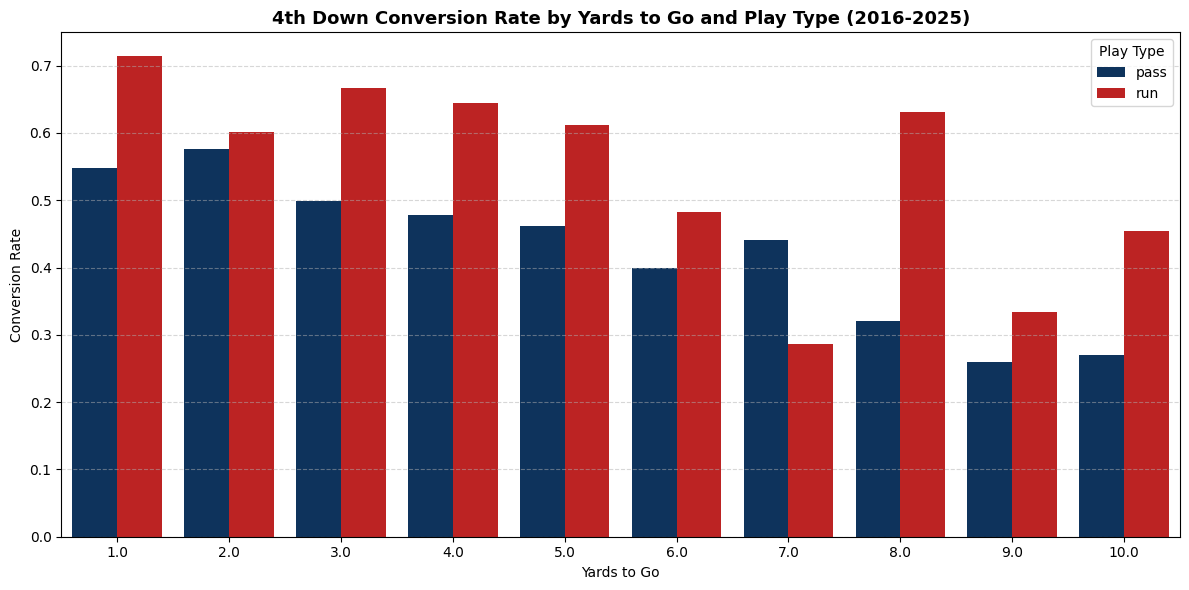

In [4]:
# Conversion rate by yards to go and play type
ydstogo_conv = go_for_it[go_for_it['ydstogo'] <= 10].groupby(
    ['ydstogo', 'play_type']
)['converted'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=ydstogo_conv, x='ydstogo', y='converted', 
            hue='play_type',
            palette={'pass': '#013369', 'run': '#D50A0A'})
plt.title('4th Down Conversion Rate by Yards to Go and Play Type (2016-2025)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Yards to Go')
plt.ylabel('Conversion Rate')
plt.legend(title='Play Type')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "conversion_by_ydstogo.png"), dpi=150)
plt.show()

![Conversion Rate by Yards to Go and Play Type](../outputs/figures/conversion_by_ydstogo.png)

The run conversion advantage holds across **every single distance** from 1 to 10 yards — this is not a situational artifact. Runs outperform passes on 4th down regardless of how far teams need to go.

Key observations:
- **4th and 1** — runs convert at 71% vs passes at 55%. Even in the shortest yardage situation where passing is most viable, runs still win by 16 percentage points
- **4th and 3-5** — the gap widens, with runs converting at 61-67% while passes sit at 46-50%
- **4th and 7** — the most surprising data point. Run conversion drops to 29% while pass holds at 44%, the only distance where passing outperforms running
- **4th and 8** — runs spike back up to 63%, suggesting teams are selecting favorable run situations at this distance
- **4th and 9-10** — both play types struggle, but runs still maintain a modest edge

The consistent run advantage raises a genuine strategic question: are NFL teams systematically underutilizing the run on 4th down? The data suggests yes — teams pass 63% of the time despite runs converting at a significantly higher rate across almost every distance.

---

### Play Type Usage by Yards to Go
How does teams' pass/run selection actually vary by distance? Are they passing more on longer yardage situations?

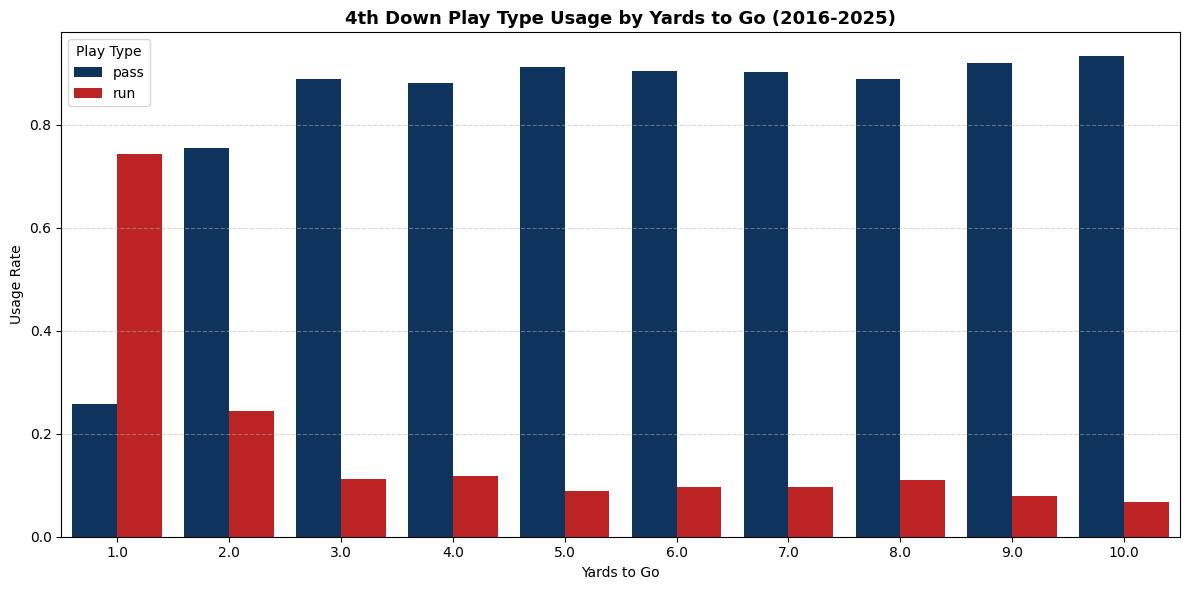

In [5]:
# Play type usage by yards to go
ydstogo_usage = go_for_it[go_for_it['ydstogo'] <= 10].groupby(
    ['ydstogo', 'play_type']
).size().reset_index(name='count')

ydstogo_total = go_for_it[go_for_it['ydstogo'] <= 10].groupby('ydstogo').size().reset_index(name='total')
ydstogo_usage = ydstogo_usage.merge(ydstogo_total, on='ydstogo')
ydstogo_usage['rate'] = ydstogo_usage['count'] / ydstogo_usage['total']

plt.figure(figsize=(12, 6))
sns.barplot(data=ydstogo_usage, x='ydstogo', y='rate',
            hue='play_type',
            palette={'pass': '#013369', 'run': '#D50A0A'})
plt.title('4th Down Play Type Usage by Yards to Go (2016-2025)',
          fontsize=13, fontweight='bold')
plt.xlabel('Yards to Go')
plt.ylabel('Usage Rate')
plt.legend(title='Play Type')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "play_type_usage_by_ydstogo.png"), dpi=150)
plt.show()

![Play Type Usage by Yards to Go](../outputs/figures/play_type_usage_by_ydstogo.png)

This chart reveals a dramatic and telling pattern in how teams select plays on 4th down:

- **4th and 1** — the only distance where runs are the majority call at 75%. This is the one situation where conventional wisdom aligns with the conversion data
- **4th and 2** — already flipping, with passes now at 75% despite runs still converting at a higher rate
- **4th and 3 through 10** — passes dominate at 88-93% usage across every distance, with runs barely registering at 7-12%

This is the most important finding in this notebook. Teams are running on 4th down almost exclusively on 4th and 1, then abandoning the run almost entirely from 4th and 2 onward — despite the conversion data showing runs outperform passes at every distance up to 10 yards except 4th and 7.

The implication is clear: **NFL teams are systematically under-utilizing the run on 4th down**. The conventional wisdom that passing is necessary on longer yardage situations is not supported by the conversion data.

---

### Coach Conversion Rates
Which coaches convert most efficiently when they go for it? We rank all qualified coaches by conversion rate on go-for-it plays.

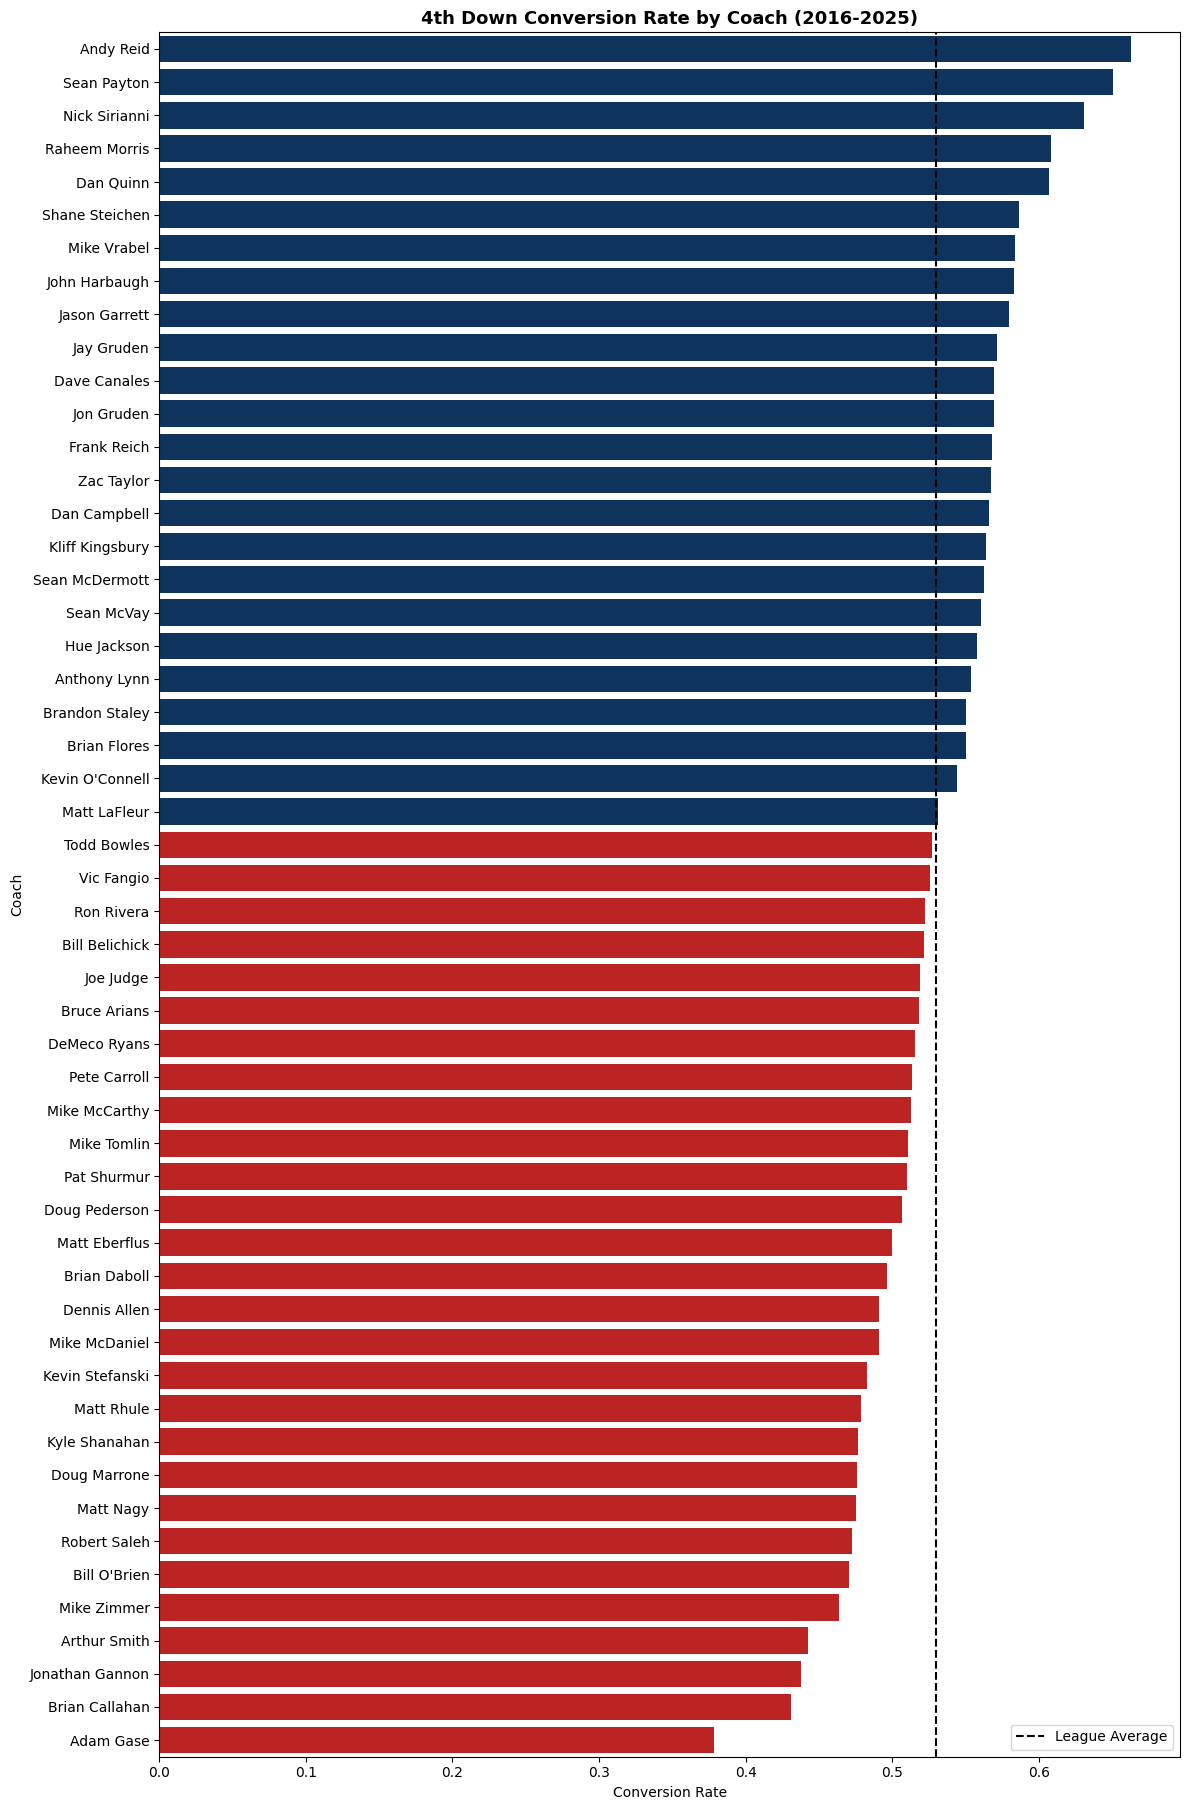

Total qualified coaches: 52
League average conversion rate: 52.98%


In [7]:
# Coach conversion rates (minimum 50 go-for-it plays to qualify)
coach_conv = go_for_it.groupby('coach').agg(
    go_attempts=('converted', 'count'),
    conversion_rate=('converted', 'mean'),
    pass_rate=('play_type', lambda x: (x == 'pass').sum() / len(x))
).reset_index()

coach_conv = coach_conv[coach_conv['go_attempts'] >= 50].sort_values('conversion_rate', ascending=False)

n_coaches = len(coach_conv)
fig_height = max(10, n_coaches * 0.35)
league_avg = coach_conv['conversion_rate'].mean()

coach_conv['color'] = coach_conv['conversion_rate'].apply(
    lambda x: '#013369' if x >= league_avg else '#D50A0A'
)

plt.figure(figsize=(12, fig_height))
sns.barplot(data=coach_conv, x='conversion_rate', y='coach', 
            hue='coach', palette=dict(zip(coach_conv['coach'], coach_conv['color'])),
            legend=False)
plt.axvline(x=league_avg, color='black', linestyle='--', linewidth=1.5, label='League Average')
plt.title('4th Down Conversion Rate by Coach (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Conversion Rate')
plt.ylabel('Coach')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_conversion_rate.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total qualified coaches: {n_coaches}")
print(f"League average conversion rate: {league_avg:.2%}")

![4th Down Conversion Rate by Coach](../outputs/figures/coach_conversion_rate.png)

The league average conversion rate on go-for-it plays is **53%**, but there is significant spread across coaches.

**Top converters (blue):**
- **Andy Reid (67%)** — the best conversion rate in the league, reinforcing his position as one of the most effective 4th down coaches by every metric in this analysis
- **Sean Payton (66%)** and **Nick Sirianni (65%)** — both elite converters, suggesting strong situational play calling when they commit to going for it
- **Raheem Morris, Dan Quinn, Shane Steichen** — all newer coaches converting at well above league average

**Worst converters (red):**
- **Adam Gase (38%)** — the worst conversion rate in the dataset by a significant margin
- **Brian Callahan, Jonathan Gannon, Arthur Smith** — all converting below 45%
- **Kyle Shanahan (46%)** — surprising given his reputation as one of the league's most creative offensive minds

**The most interesting cross-reference:** Dan Campbell converts at 54% — just above league average — despite being the most aggressive coach in the dataset. He goes for it the most but doesn't convert at an elite rate, which helps explain why his WPA numbers are strong but not at the very top.

---

### EPA on Go-For-It Plays by Coach
Conversion rate alone doesn't tell the full story — a short gain that converts is worth less than a big play that converts. EPA captures the full value of each go-for-it attempt.

### EPA on Go-For-It Plays by Coach
Which coaches generate the most value per go-for-it attempt? Average EPA per play captures not just whether they convert but how much each attempt moves the needle.

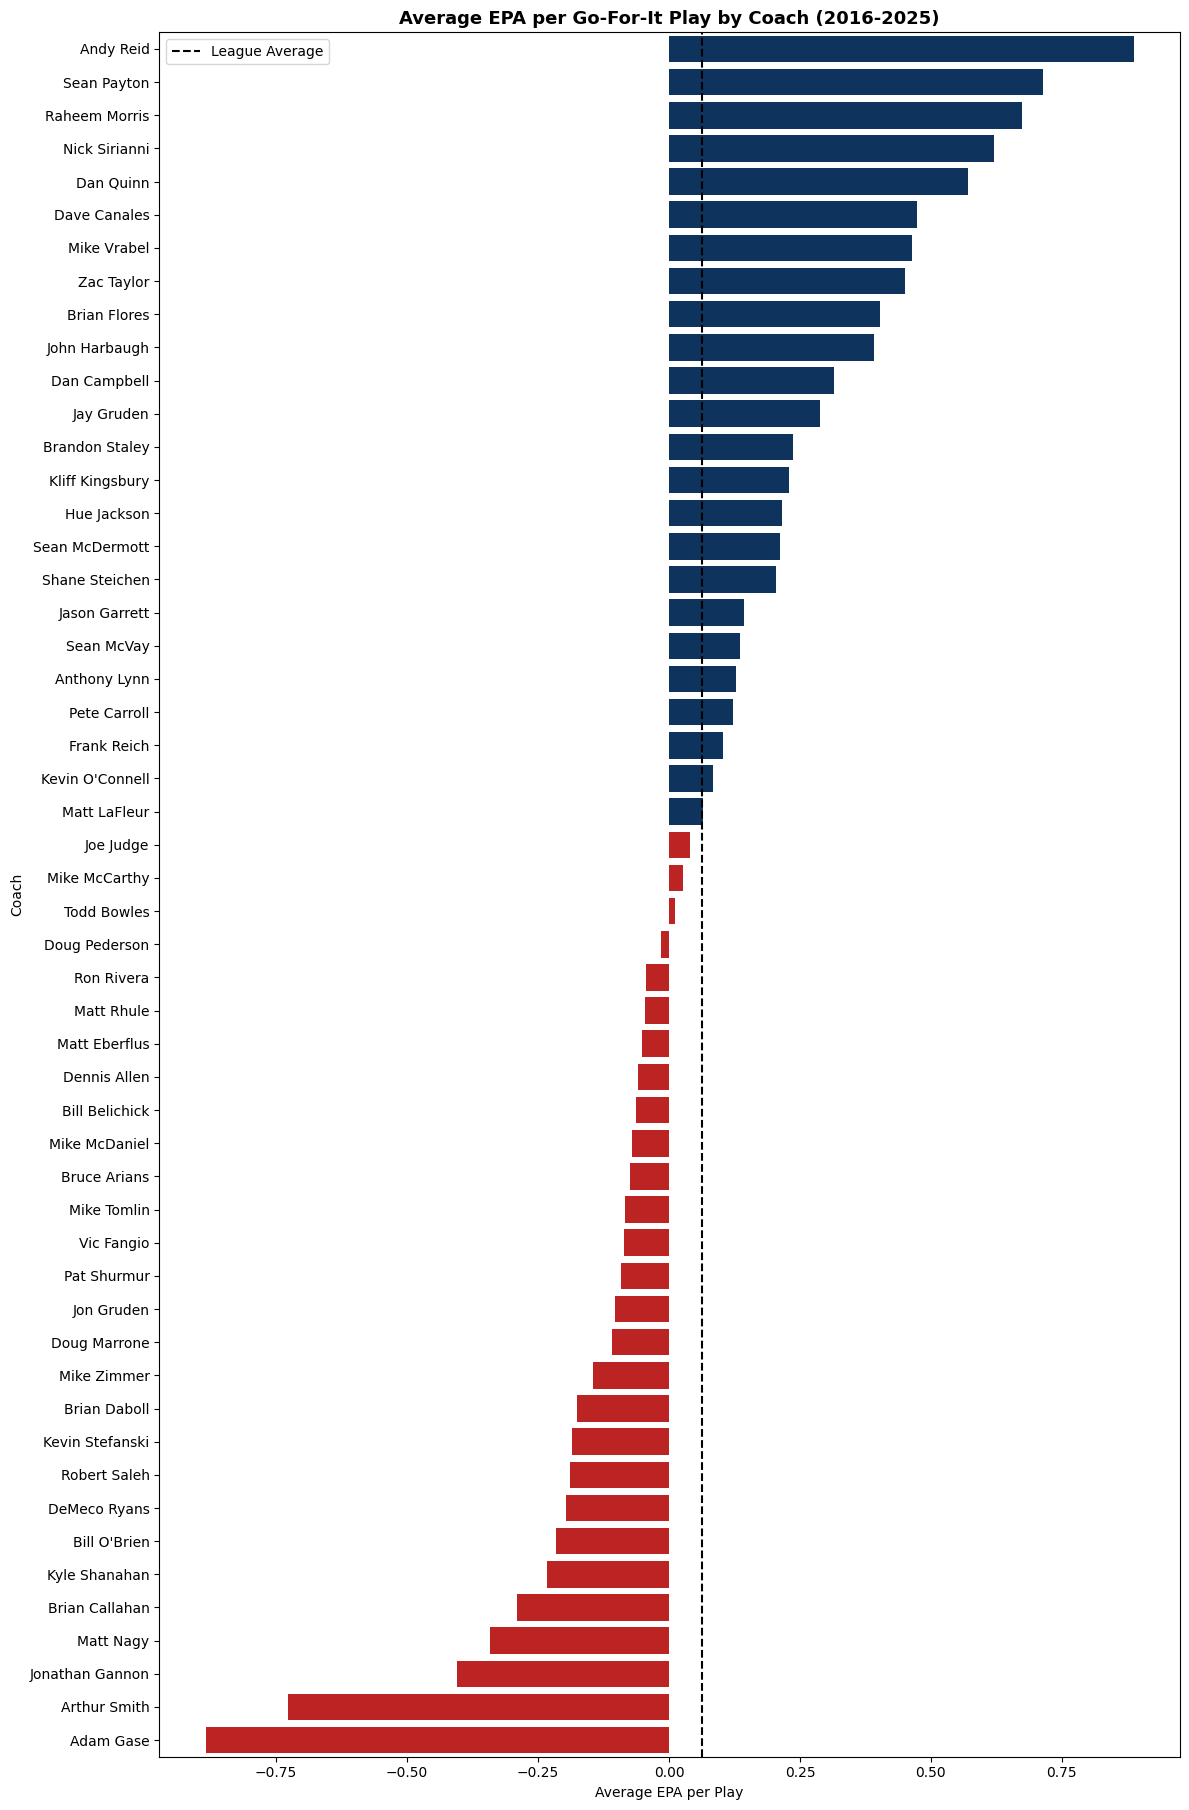

League average EPA per go-for-it: 0.064


In [8]:
# EPA on go-for-it plays by coach (minimum 50 attempts)
coach_epa = go_for_it.groupby('coach').agg(
    go_attempts=('epa', 'count'),
    avg_epa=('epa', 'mean')
).reset_index()

coach_epa = coach_epa[coach_epa['go_attempts'] >= 50].sort_values('avg_epa', ascending=False)

n_coaches = len(coach_epa)
fig_height = max(10, n_coaches * 0.35)
league_avg_epa = coach_epa['avg_epa'].mean()

coach_epa['color'] = coach_epa['avg_epa'].apply(
    lambda x: '#013369' if x >= league_avg_epa else '#D50A0A'
)

plt.figure(figsize=(12, fig_height))
sns.barplot(data=coach_epa, x='avg_epa', y='coach',
            hue='coach', palette=dict(zip(coach_epa['coach'], coach_epa['color'])),
            legend=False)
plt.axvline(x=league_avg_epa, color='black', linestyle='--', linewidth=1.5, label='League Average')
plt.title('Average EPA per Go-For-It Play by Coach (2016-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Average EPA per Play')
plt.ylabel('Coach')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "coach_epa_go_for_it.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"League average EPA per go-for-it: {league_avg_epa:.3f}")

![Average EPA per Go-For-It Play by Coach](../outputs/figures/coach_epa_go_for_it.png)

EPA per go-for-it attempt tells a more complete story than conversion rate alone — it captures the magnitude of success and failure, not just the binary outcome.

**Top EPA generators (blue):**
- **Andy Reid** leads by a wide margin, generating nearly 0.9 EPA per go-for-it attempt — an extraordinary number that reflects both high conversion rates and big plays when successful
- **Sean Payton (0.75)** and **Raheem Morris (0.70)** — both elite, consistent with their strong conversion rates
- **Nick Sirianni, Dan Quinn, Dave Canales** — all generating strong positive EPA, suggesting smart situational usage

**Worst EPA performers (red):**
- **Adam Gase (-0.85)** — the worst in the dataset by a significant margin, combining a low conversion rate with poor play outcomes when he does go for it
- **Arthur Smith (-0.70)** and **Jonathan Gannon (-0.55)** — both significantly negative, suggesting poor play calling quality on go-for-it attempts
- **Kyle Shanahan (-0.25)** — continues to underperform on go-for-it plays despite his offensive reputation
- **Kevin Stefanski (-0.28)** — notable given his high go-for-it volume, suggesting he is going for it in the wrong situations

**The Andy Reid finding** ties everything together across notebooks — he ranks first in WPA, first in conversion rate, and first in EPA on go-for-it plays. By every metric in this analysis he is the best 4th down decision maker in the NFL over the past decade.

---

### Summary
This notebook reveals several key findings about what happens when NFL coaches go for it on 4th down:

1. **Teams pass 63% of the time** on go-for-it plays despite runs converting at a significantly higher rate across almost every distance
2. **Runs outperform passes at every distance from 1-10 yards** except 4th and 7, suggesting teams are systematically underutilizing the run
3. **The overall conversion rate is 53%** but ranges from 38% (Adam Gase) to 67% (Andy Reid) across coaches
4. **Andy Reid is the best go-for-it coach in the NFL** by conversion rate, EPA, and WPA — a consistent finding across every metric in this analysis
5. **Aggressiveness and execution are independent skills** — Dan Campbell goes for it the most but converts at only league average, while Andy Reid goes for it less but executes far better